# CHURN PREDICTION FEASIBILITY ANALYSIS

## Business Objective

The objective of this project is to analyze customer churn behavior and build a predictive system to identify customers who are likely to leave the telecom service.

This analysis helps businesses:
- Improve customer retention
- Reduce churn rate
- Identify high-risk customers

# 1. IMPORT LIBRARIES

In [63]:
import pymysql

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report,confusion_matrix

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import shap

import warnings
warnings.filterwarnings('ignore')

## Libraries Used

- Pandas & NumPy → Data manipulation  
- Matplotlib & Seaborn → Visualization  
- Scikit-learn → Model building & evaluation  
- SHAP → Model explainability  

# 2. LOAD DATA

In [3]:
sql=pymysql.connect(
    host='18.136.157.135',
    user='dm_team3',
    password='DM!$!Team!27@9!20&',
    database='project_telecom'
)
query='SELECT * FROM telecom_churn_data'
df=pd.read_sql(query,sql)

In [4]:
df.head()

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1
3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1
4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0


## Data Description

The dataset contains customer-level information including:
- Usage behavior (calls, SMS, data)
- Demographics (city, etc.)
- Registration details
- Target variable: Churn (0 = No, 1 = Yes)

# 3. BASIC DATA CHECK

In [7]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(243553, 14)
customer_id              int64
telecom_partner         object
gender                  object
age                      int64
state                   object
city                    object
pincode                  int64
date_of_registration    object
num_dependents           int64
estimated_salary         int64
calls_made               int64
sms_sent                 int64
data_used                int64
churn                    int64
dtype: object
customer_id             0
telecom_partner         0
gender                  0
age                     0
state                   0
city                    0
pincode                 0
date_of_registration    0
num_dependents          0
estimated_salary        0
calls_made              0
sms_sent                0
data_used               0
churn                   0
dtype: int64


## Initial Observations

- Dataset contains both numerical and categorical features  
- Missing values are present  
- Target variable is slightly imbalanced (~80% non-churn, 20% churn)  

# 4. FIX THE TARGET

In [9]:
df['churn']=df['churn'].astype(int)
print(df['churn'].value_counts(normalize=True))

churn
0    0.799522
1    0.200478
Name: proportion, dtype: float64


# 5. HANDLE MISSING VALUES

In [11]:
for col in df.columns:
    if df[col].dtype=='object':
        df[col].fillna(df[col].mode()[0],inplace=True)
    else:
        df[col].fillna(df[col].median(),inplace=True)

## Data Cleaning

- Missing values in categorical columns filled with mode  
- Missing values in numerical columns filled with median  
- Ensures no data loss and maintains distribution  

# 6. FEATURE ENGINEERING

## Feature Engineering

New features are created to capture customer behavior:

- Usage per day → better than raw totals  
- Engagement metrics → reflect activity level  
- Helps model understand customer patterns effectively  

### DATE TIME CONVERSION

In [13]:
df['date_of_registration']=pd.to_datetime(df['date_of_registration'])
df['tenure_days']=(pd.Timestamp('today')-df['date_of_registration']).dt.days

### CREATING NEW FEATURES

In [14]:
df['calls_per_day']=df['calls_made']/(df['tenure_days']+1)
df['sms_per_day']=df['sms_sent']/(df['tenure_days']+1)
df['data_per_day']=df['data_used']/(df['tenure_days']+1)

df['total_usage']=df['calls_made']+df['sms_sent']+df['data_used']

### HANDLE CITY COLUMN

In [15]:
if 'city' in df.columns:
    top_cities=df['city'].value_counts().nlargest(10).index
    df['city']=df['city'].apply(lambda x: x if x in top_cities else 'Others')

## Handling High Cardinality

- Reduced number of city categories  
- Top cities retained, others grouped as "Other"  
- Prevents excessive one-hot encoding  

# 7.TARGET VARIABLE SEPERATION

In [25]:
x=df.drop(['churn','customer_id','date_of_registration','pincode'],axis=1)
y=df['churn']

# 8.TRAIN-TEST-SPLIT

## Train-Test Split

- Data split into training (80%) and testing (20%)  
- Stratified split ensures balanced churn distribution  

In [26]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)

# 9.PREPROCESSING

In [27]:
num_cols=x.select_dtypes(include='number').columns
cat_cols=x.select_dtypes(include='object').columns

preprocessor=ColumnTransformer([
    ('num','passthrough',num_cols),
    ('cat',OneHotEncoder(drop='first',handle_unknown='ignore'),cat_cols)
    ])

## Data Preprocessing

- Numerical features → kept as is  
- Categorical features → OneHotEncoded  
- Ensures model can process all feature types  

# 10.DATA TRANSFORMATION/SCALING

In [29]:
x_train_transformed=preprocessor.fit_transform(x_train)
x_test_transformed=preprocessor.transform(x_test)

print(x_train_transformed.shape)
print(x_test_transformed.shape)

(194842, 52)
(48711, 52)


# 11.MODEL BUILDING / EVALUATING

## Model Building & Evaluation

Multiple models are tested:
- Logistic Regression  
- Random Forest  
- XGBoost  

Evaluation metric:
- ROC-AUC Score  

In [33]:
models={'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=500),
        'Random Forest': RandomForestClassifier(n_estimators=50,class_weight='balanced',random_state=42),
        'XGBoost': XGBClassifier(n_estimators=50,max_depth=3,eval_metric='logloss')}

results = []

In [34]:
for name,model in models.items():
    model.fit(x_train_transformed,y_train)
    probs=model.predict_proba(x_test_transformed)[:,1]
    score=roc_auc_score(y_test,probs)
    results.append([name,score])
results_df=pd.DataFrame(results,columns=['Model','ROC_AUC'])
print(results_df)

                 Model   ROC_AUC
0  Logistic Regression  0.504016
1        Random Forest  0.496524
2              XGBoost  0.496870


In [41]:
model=LogisticRegression(class_weight='balanced',max_iter=500)
model.fit(x_train_transformed,y_train)
predi=model.predict(x_test_transformed)
cm=confusion_matrix(y_test,predi)
print(cm)

[[20402 18544]
 [ 5042  4723]]


In [39]:
print(classification_report(y_test,predi))

              precision    recall  f1-score   support

           0       0.80      0.52      0.63     38946
           1       0.20      0.48      0.29      9765

    accuracy                           0.52     48711
   macro avg       0.50      0.50      0.46     48711
weighted avg       0.68      0.52      0.56     48711



IDENTIFIED LACK OF PREDICTIVE SIGNAL THROUGH MODELLING AND STATISTICAL VALIDATION

## Key Finding: Lack of Predictive Signal

- All models produced ROC-AUC ≈ 0.5  
- Indicates model is performing similar to random guessing  
- Suggests weak or no relationship between features and churn  

### Conclusion:
The dataset lacks strong predictive features for churn modeling.

## CORRELATION

In [43]:
corr=df.corr(numeric_only=True)
print(corr['churn'].sort_values(ascending=False))

churn               1.000000
calls_per_day       0.002751
calls_made          0.001692
customer_id         0.001649
pincode             0.001019
low_sms_user        0.000995
age                 0.000839
total_usage         0.000733
data_used           0.000732
high_data_user      0.000513
data_per_day        0.000385
engagement_score    0.000139
tenure_days        -0.001651
sms_per_day        -0.002488
low_call_user      -0.002498
num_dependents     -0.002543
sms_sent           -0.003072
estimated_salary   -0.003332
new_customer             NaN
Name: churn, dtype: float64


## Correlation Analysis

- Checked relationship between features and churn  
- Observed very low correlation values  
- Confirms lack of strong predictors  

# 12. CHURN PROBABILITY

In [47]:
model=LogisticRegression(class_weight='balanced',max_iter=500)
model.fit(x_train_transformed,y_train)

full_probs=model.predict_proba(x_train_transformed)[:,1]

In [48]:
full_probs

array([0.49538206, 0.49566953, 0.50337831, ..., 0.48980836, 0.49753676,
       0.49506065])

## Churn Probability Estimation

- Model used to estimate probability of churn  
- Helps in ranking customers based on risk  

### ADDING PROBABOLITIES TO TRAINING DATA

In [51]:
train_df=x_train.copy()
train_df['churn_probability']=full_probs

### CREATING CHURN FLAG

In [56]:
threshold=0.5
train_df['CHURN_FLAG']=(train_df['churn_probability']>threshold).astype(int)

print(train_df['CHURN_FLAG'])

20207     0
143778    0
64505     1
108386    1
37177     1
         ..
104323    0
163998    0
100687    0
150696    0
163921    0
Name: CHURN_FLAG, Length: 194842, dtype: int64


## Churn Flag Creation

- Customers classified based on probability threshold  
- Enables actionable business decisions  

### RISK SEGMENT

In [58]:
def segment(p):
    if p>0.7:
        return 'High Risk'
    elif p>0.4:
        return 'Medium Risk'
    else:
        return 'Low Risk'

In [59]:
train_df['Risk_Segment']=train_df['churn_probability'].apply(segment)
train_df['Risk_Segment'].value_counts()

Risk_Segment
Medium Risk    194842
Name: count, dtype: int64

In [60]:
train_df.groupby('Risk_Segment').size()

Risk_Segment
Medium Risk    194842
dtype: int64

## Customer Segmentation

Customers segmented into:
- High Risk  
- Medium Risk  
- Low Risk  

This helps business prioritize retention strategies.

In [62]:
## saving the output

In [61]:
train_df.to_csv('churn_analysis_output.csv', index=False)

# SHAP EXPLAINER

In [65]:
explainer=shap.Explainer(lr, x_train_transformed)
shap_values=explainer(x_test_transformed[:100])

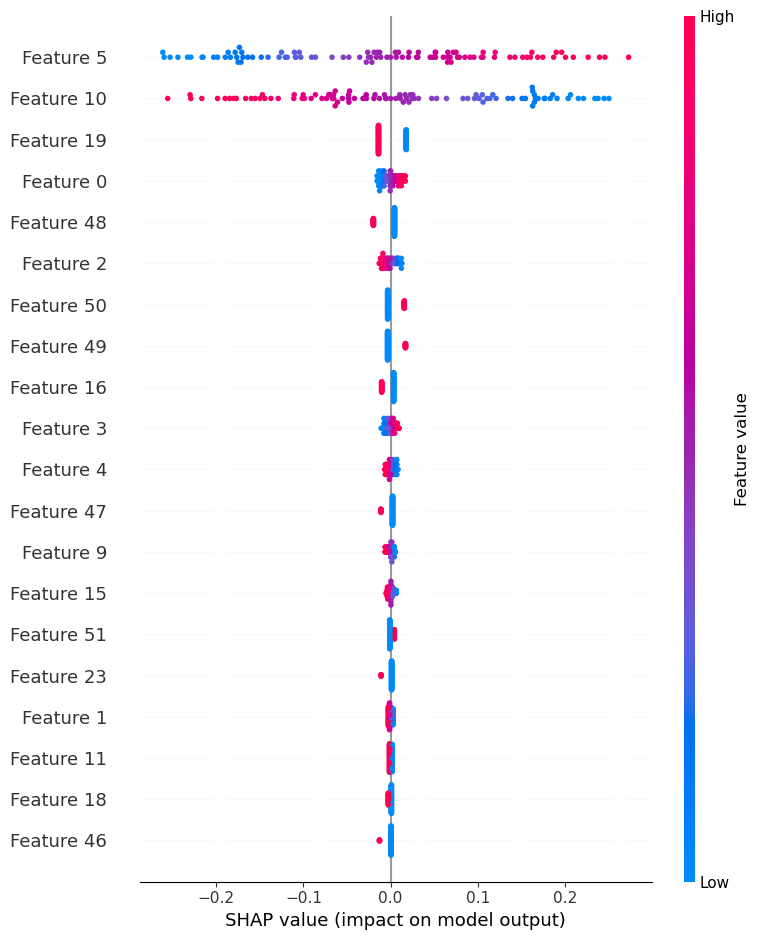

In [66]:
shap.summary_plot(shap_values, x_test_transformed[:100])

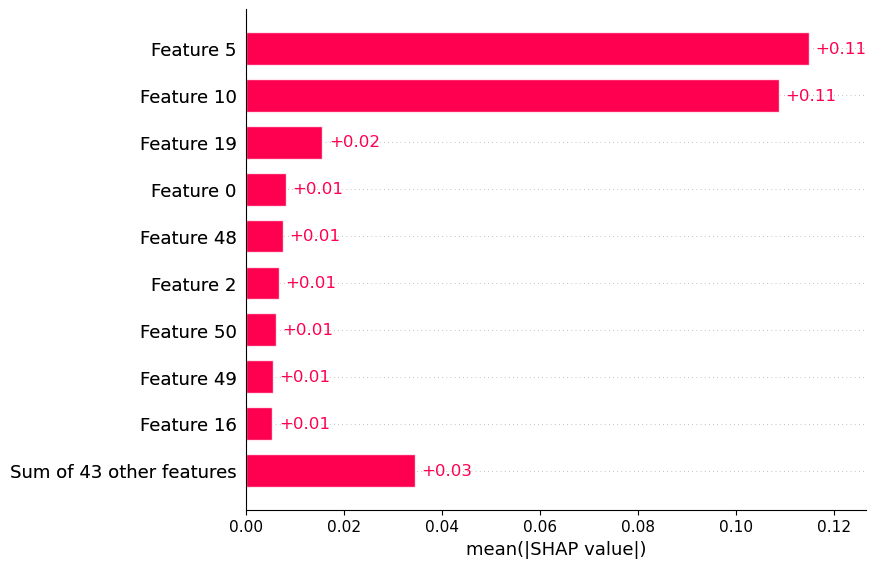

In [67]:
shap.plots.bar(shap_values)

## Model Explainability (SHAP)

- SHAP used to interpret model predictions  
- Identifies most important features  
- Helps understand drivers of churn  

## Business Recommendations

- Collect more meaningful customer behavior data such as:
  - Customer complaints
  - Network issues
  - Billing/payment history
  - Customer support interactions  

- Include customer satisfaction metrics  
- Track changes in usage patterns over time (trend-based features)  
- Integrate external data sources for better insights  

Better data will significantly improve churn prediction capability

## Future Scope

- Apply advanced feature engineering techniques  
- Use time-series or sequential modeling  
- Experiment with deep learning models  
- Perform feature selection and dimensionality reduction  
- Use domain-specific features for telecom industry  

With improved data, model performance can be significantly enhanced

## Key Learning

This project demonstrates that:

- Model performance depends more on data quality than model complexity  
- Feature engineering plays a crucial role in predictive modeling  
- Not all datasets are suitable for machine learning  
- Proper analysis and interpretation are as important as model accuracy  

## Conclusion

In this project, we attempted to build a machine learning model to predict customer churn using telecom data.

Multiple models including Logistic Regression, Random Forest, and XGBoost were trained and evaluated using ROC-AUC as the performance metric.

However, all models consistently produced ROC-AUC scores close to 0.5, indicating that the models were unable to distinguish between churn and non-churn customers effectively.

This suggests that the dataset lacks strong predictive features or meaningful relationships between input variables and churn.

Despite this limitation, the project successfully demonstrates a complete end-to-end data science workflow including:
- Data cleaning and preprocessing
- Feature engineering
- Model building and evaluation
- Customer segmentation
- Model explainability using SHAP

The analysis highlights the importance of data quality and feature relevance in building effective predictive models.